In [1]:
!pip3 install -q numpy
!pip3 install -q scipy
!pip3 install -q pillow
!pip3 install -q opencv-python
!pip3 install -q matplotlib
# !pip3 install -q torch torchvision torchaudio
!pip3 install -q tqdm

You should consider upgrading via the 'c:\users\harsh\desktop\test1\env\scripts\python.exe -m pip install --upgrade pip' command.
You should consider upgrading via the 'c:\users\harsh\desktop\test1\env\scripts\python.exe -m pip install --upgrade pip' command.
You should consider upgrading via the 'c:\users\harsh\desktop\test1\env\scripts\python.exe -m pip install --upgrade pip' command.
You should consider upgrading via the 'c:\users\harsh\desktop\test1\env\scripts\python.exe -m pip install --upgrade pip' command.
You should consider upgrading via the 'c:\users\harsh\desktop\test1\env\scripts\python.exe -m pip install --upgrade pip' command.
You should consider upgrading via the 'c:\users\harsh\desktop\test1\env\scripts\python.exe -m pip install --upgrade pip' command.


## **Question 1**
Write two functions **compute_gradient_magnitude(gr_im, kx, ky)** and **compute_gradient_direction(gr_im, kx, ky)** to compute the magnitude and direction of gradient of the grey image gr_im with the horizontal kernel kx and vertical kernel ky.

### Inputs
• gr_im is a 2-dimensional numpy array of data type uint8 with values in [0,255] </br>
• kx and ky are 2 dimensional numpy arrays of data type uint8.

### Outputs
• The expected outputs are two 2-dimensional numpy array of the same shape as of gr_im and of data type float64.

### Data
• You can work with the image at data/shapes.png.


In [2]:
import cv2
import numpy as np
from scipy.signal import convolve2d
from PIL import Image
import matplotlib.pyplot as plt

%matplotlib inline

In [3]:
def compute_gradient_magnitude(gr_im, kx, ky):
    """Computes the magnitude of the gradient of a grayscale image.

    Args:
        gr_im: 2D numpy array of uint8, grayscale image.
        kx: 2D numpy array of uint8, horizontal kernel.
        ky: 2D numpy array of uint8, vertical kernel.

    Returns:
        2D numpy array of float64, gradient magnitude.
    """

    gx = convolve2d(gr_im, kx, mode='same')
    gy = convolve2d(gr_im, ky, mode='same')
    gradient_magnitude = np.sqrt(gx**2 + gy**2)
    gradient_magnitude = gradient_magnitude.astype(np.float64)
    return gradient_magnitude

In [4]:
def compute_gradient_direction(gr_im, kx, ky):
    """Computes the direction of the gradient of a grayscale image.

    Args:
        gr_im: 2D numpy array of uint8, grayscale image.
        kx: 2D numpy array of uint8, horizontal kernel.
        ky: 2D numpy array of uint8, vertical kernel.

    Returns:
        2D numpy array of float64, gradient direction in radians.
    """

    gx = convolve2d(gr_im, kx, mode='same')
    gy = convolve2d(gr_im, ky, mode='same')
    gradient_direction = np.arctan2(gy, gx)  # Returns values in radians
    return gradient_direction


In [5]:
gr_im = Image.open("data/shapes.png").convert('L')

kx = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
ky = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])

gradient_magnitude = compute_gradient_magnitude(gr_im, kx, ky)
gradient_direction = compute_gradient_direction(gr_im, kx, ky)

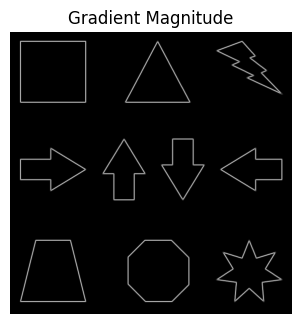

In [6]:
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(gradient_magnitude, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')
plt.savefig('Question 1-Gradient Magnitude.png')

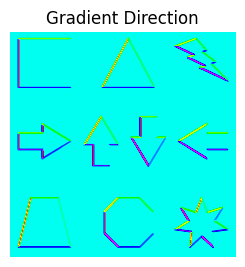

In [7]:
plt.subplot(1, 2, 2)
plt.imshow(gradient_direction, cmap='hsv')
plt.title('Gradient Direction')
plt.axis('off')
plt.savefig('Question 1-Gradient Direction.png')

## Question 2
Write a function generate_bovw_spatial_histogram(im, locations, clusters, division) to create bag of visual words representation of an image im whose features are located at locations and the quantised labels of those features are stored in clusters. You have to build the histogram based on the division information provided in division. For example, if division = [2, 3], you have to imagine dividing the image along Y-axis in 2 parts and along X-axis in 3 parts (as shown in the right most figure below), else if division = [2, 2], you have to imagine dividing
       
the image in 2 parts along both the axes, else if division = [1, 1], you just compute the bag-of- visual-words histogram on the entire image without dividing into any parts. You have to showcase three test cases to call the above function in order to calculate the bag-of-visual- words spatial histograms on the image im showcasing coarse and fine divisions.

### Inputs
• im is a 3-dimensional numpy array of data type uint8.
• locations is a 2-dimensional numpy array of shape 𝑁 × 2 of data type int64, whose each row is a Cartesian coordinate (𝑥,𝑦) .
• clusters is a 1-dimensional numpy array of shape (𝑁,) of data type int64, whose each element indicates the quantised cluster id.
• division is a list of integers of length 2.

### Outputs
• This function should return a 1-dimensional numpy array of data type int64. The results for all three test cases should be saved and submitted along with the information in the report on the division numbers and the corresponding output filenames.

### Data
• There is no specific data for this question. However, you can create data using one of the images available inside the data folder.

In [8]:
def generate_bovw_spatial_histogram(im, locations, clusters, division):
    """
    This function generates a bag-of-visual-words (BoVW) spatial histogram of an image.

    Args:
      im: The image as a numpy array.
      locations: A numpy array of locations of features in the image.
      clusters: A numpy array of quantized labels of the features.
      division: A list of integers specifying the division of the image.

    Returns:
      A numpy array representing the BoVW spatial histogram.
    """

    # Calculate the number of segments along each axis
    segments_y, segments_x = division

    # Calculate the height and width of each segment
    segment_height = im.shape[0] // segments_y
    segment_width = im.shape[1] // segments_x

    # Initialize an empty list to store histograms for each segment
    histograms = []

    # Iterate over each segment
    for y in range(segments_y):
        for x in range(segments_x):
            # Calculate the coordinates of the current segment
            y_start = y * segment_height
            y_end = (y + 1) * segment_height
            x_start = x * segment_width
            x_end = (x + 1) * segment_width

            # Extract features and clusters within the current segment
            segment_locations = locations[(locations[:, 0] >= x_start) & (locations[:, 0] < x_end) &
                                          (locations[:, 1] >= y_start) & (locations[:, 1] < y_end)]
            segment_clusters = clusters[(locations[:, 0] >= x_start) & (locations[:, 0] < x_end) &
                                        (locations[:, 1] >= y_start) & (locations[:, 1] < y_end)]

            # Compute histogram for the current segment
            histogram, _ = np.histogram(segment_clusters, bins=np.arange(clusters.max() + 2))

            # Append histogram to the list of histograms
            histograms.append(histogram)

    # Concatenate histograms to create the final BoVW spatial histogram
    bovw_histogram = np.concatenate(histograms)

    return bovw_histogram.astype(np.int64)


BoVW spatial histogram (1, 1): [65 77 84 86 73 78 68 67 78 75]
BoVW spatial histogram (2, 2): [22 17 23 21 20 19 19 15 32 18 13 22 25 26 22 20 22 16 10 16 17 19 23 14
 14 17 14 16 18 24 13 19 13 25 17 22 13 20 18 17]
BoVW spatial histogram (3, 2): [16 12 15 14 16 10 15 11 21 12  8 17 24 14 12  8 17  8  8  9 10 11 16 10
  8 13  6  8 20 12  8 11  6 19 16 24  9 15  7 12 13 13 15 11 10 13 12 12
  9 18 10 13  8 18 11 10  9 13 13 12]


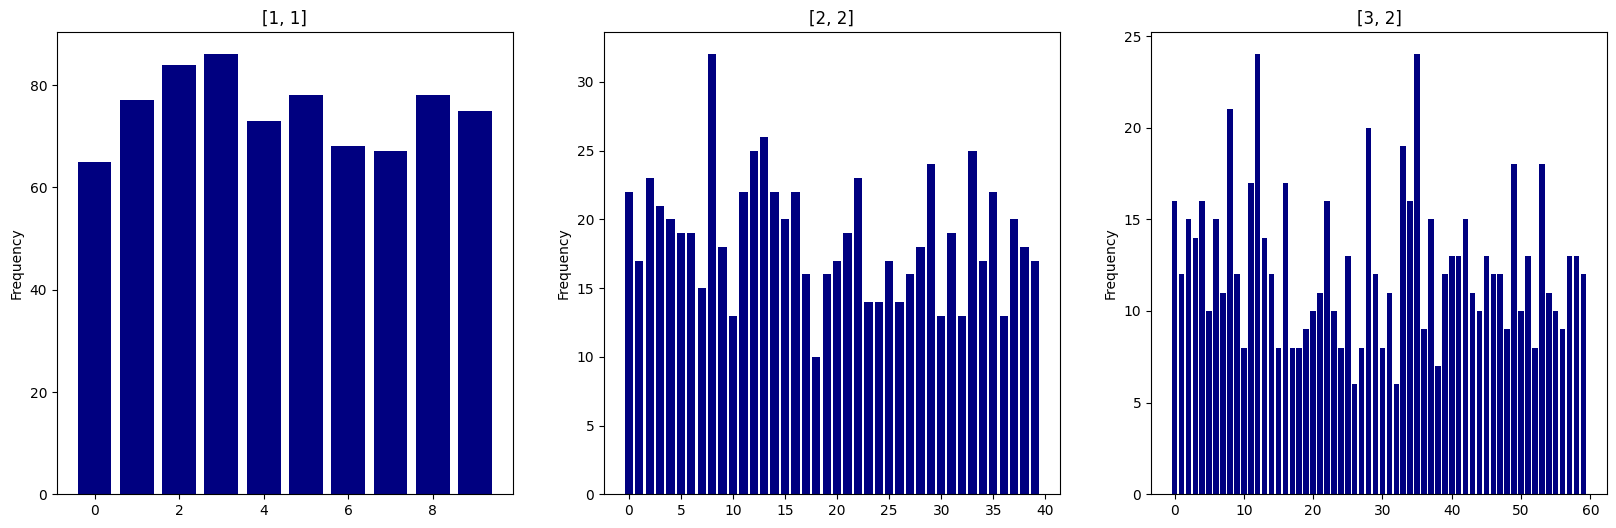

In [9]:
im = Image.open('data/books.jpg')
im = np.array(im)

locations = np.random.randint(0, im.shape[1], size=(im.shape[1], 2))
clusters = np.random.randint(0, 10, size=im.shape[1])

# Coarse division (1x1)
division = [1, 1]
hist_coarse = generate_bovw_spatial_histogram(im.copy(), locations.copy(), clusters.copy(), division)
print("BoVW spatial histogram (1, 1):", hist_coarse)
np.save('Histogram Case (1, 1).npy', hist_coarse)

# Medium division (2x2)
division = [2, 2]
hist_medium = generate_bovw_spatial_histogram(im.copy(), locations.copy(), clusters.copy(), division)
print("BoVW spatial histogram (2, 2):", hist_medium)
np.save('Histogram Case (2, 2).npy', hist_medium)

# Fine division (3x2)
division = [3, 2]
hist_fine = generate_bovw_spatial_histogram(im.copy(), locations.copy(), clusters.copy(), division)
print("BoVW spatial histogram (3, 2):", hist_fine)
np.save('Histogram Case (3, 2).npy', hist_fine)

plt.figure(figsize=(20, 6))  # Set wider figure size
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.cm.jet(np.linspace(0, 1, 10)))  # Set colorful cycle

# Plot coarse histogram
plt.subplot(1, 3, 1)
plt.bar(np.arange(len(hist_coarse.flatten())), hist_coarse.flatten())
plt.title('[1, 1]')
plt.ylabel('Frequency')

# Plot medium histogram
plt.subplot(1, 3, 2)
plt.bar(np.arange(len(hist_medium.flatten())), hist_medium.flatten())
plt.title('[2, 2]')
plt.ylabel('Frequency')

# Plot fine histogram
plt.subplot(1, 3, 3)
plt.bar(np.arange(len(hist_fine.flatten())), hist_fine.flatten())
plt.title('[3, 2]')
plt.ylabel('Frequency')

plt.savefig('Question 2 - Frequency Histogram.png')
plt.show()



## Question 3
Write a function compute_rotation_matrix(points, theta) to compute the rotation matrix in homogeneous coordinate system to rotate a shape depicted with 2-
dimensional (𝑥,𝑦) coordinates points with an angle 𝜃 (theta in the definition) in the anticlockwise direction about the centre of the shape.
    
### Inputs
• points is a 2-dimensional numpy array of data type uint8 with shape 𝑘 × 2. Each row of points is a Cartesian coordinate (𝑥,y).
• theta is a floating-point number denoting the angle of rotation in degree.

### Outputs
• The expected output is a 2-dimensional numpy array of data type float64 with shape 3×3

### Data
• You can work with 2-dimensional numpy array at data/points.npy


In [10]:
def compute_rotation_matrix(points, theta):
    """
    This function computes the rotation matrix in homogeneous coordinates to rotate
    a shape with 2D (x, y) coordinates about its center in the anticlockwise direction.

    Args:
        points: A 2D NumPy array of uint8 data type with shape (k, 2). Each row represents a point (x, y).
        theta: A floating-point number representing the rotation angle in degrees.

    Returns:
        A 2D NumPy array of float64 data type with shape (3, 3) representing the rotation matrix.
    """

    # Convert angle from degrees to radians
    theta_rad = np.radians(theta)

    # Calculate the center of the shape
    center = np.mean(points, axis=0)

    # Translate points to make shape's center the origin
    translated_points = points - center

    # Create the rotation matrix
    rotation_matrix = np.array([[np.cos(theta_rad), -np.sin(theta_rad), 0],
                                 [np.sin(theta_rad), np.cos(theta_rad), 0],
                                 [0, 0, 1]])

    return rotation_matrix

# Load points from data file (assuming data/points.npy exists)
points = np.load('data/points.npy')

# Specify rotation angle in degrees
theta = 45.3

rotation_matrix = compute_rotation_matrix(points, theta)
print("Rotation Matrix:")
print(rotation_matrix)
np.save('Question 3: Rotation Matrix.npy', hist_fine)


Rotation Matrix:
[[ 0.7033947  -0.71079947  0.        ]
 [ 0.71079947  0.7033947   0.        ]
 [ 0.          0.          1.        ]]


## Question 4

Write a function train_cnn(model, train_loader) to train the following version of the Residual Network (ResNet) model on the EXCV10 (Exeter Computer Vision 10) dataset (available at this link)

At the end of the training, this function should save the best weights of the trained CNN at: data/weights_resnet.pth. The EXCV10 dataset contains 10000 images from 10 classes which are further split into train (available at train/ folder; total 8000 images with 800 images/class) and validation (available at val/ folder; total 2000 images with 200 images/class) sets. For training your model, please feel free to decide your optimal hyperparameters, such as the number of epochs, type of optimisers, learning rate scheduler etc within the function, which can be done to optimise the performance of the model on the validation set.

### Inputs
• model is an instantiation of ResNet class which can be created as follows:
ResNet(block=BasicBlock, layers=[1, 1, 1], num_classes=num_classes). An example of this can be found in the below snippet.
• train_loader is the training data loader. You can create the dataset and data loader for your training following the example in the snippet below. Feel free to try other data augmentation and regularisation techniques to train a better model.
     
### Outputs
• This function should not necessarily return any output, instead it should save your best model at data/weights_resnet.pth.

### Data
• You can train your model on the data available at https://empslocal.ex.ac.uk/people/staff/ad735/ECMM426/EXCV10.zip. As EXCV10 dataset is quite large in size, do not upload it with your submission.

In [14]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
from torch.optim import lr_scheduler
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

def train_cnn(model, train_loader):
    # Define optimizer (Adam) and learning rate scheduler
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=5, verbose=True)

    # Define loss function
    criterion = nn.CrossEntropyLoss()

    # Initialize variables for early stopping
    best_loss = float('inf')
    epochs_without_improvement = 0
    max_epochs = 200  # Maximum number of epochs

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Train the model
    for epoch in range(max_epochs):
        running_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{max_epochs}", leave=False):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        # Calculate average loss for the epoch
        epoch_loss = running_loss / len(train_loader)
        print(f"Epoch {epoch + 1}/{max_epochs}, Loss: {epoch_loss:.4f}")

        # Update learning rate scheduler
        scheduler.step(epoch_loss)

        # Check for early stopping
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(model.state_dict(), './data/weights_resnet.pth')
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= 10:  # Patience for early stopping
                print("Early stopping triggered.")
                break




In [ ]:
from ca_utils import ResNet, BasicBlock

model = ResNet(block=BasicBlock, layers=[1, 1, 1], num_classes=10)
image_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
train_dataset = datasets.ImageFolder(root='./EXCV10/train', transform=image_transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=4, pin_memory=True)

train_cnn(model, train_loader)

C:\Users\harsh\Desktop\test1\env\lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch 1/200, Loss: 1.9103


Epoch 2/200:   0%|                                                                              | 0/63 [00:00<?, ?it/s]

## Question 5

Write a function test_cnn(model, test_loader) which will return the predicted labels by the model that you trained in the previous question for all the images supplied in the test_loader object. The test set will contain 3000 images (300 images/class) from the same distribution as of the EXCV10 dataset.

### Inputs
• model is an instantiation of ResNet class which can created as follows
ResNet(block=BasicBlock, layers=[1, 1, 1], num_classes=num_classes).
• test_loader is the data loader containing test data. The test data loader can be created
following the example in the cell below. We will only use vanilla transformation to the test dataset.

### Outputs
• This function should return a 1-dimensional numpy array of data type int64
containing the predicted labels of the images in the test_loader object.
• This function should also return the classification accuracy as a percentage

   
### Data
• You can test your model on val set of the data available at https://empslocal.ex.ac.uk/people/staff/ad735/ECMM426/EXCV10.zip. As EXCV10 dataset is quite large in size, do not upload it with your submission.

In [ ]:
class EXCV10TestImageFolder(datasets.ImageFolder):
    def _getitem_(self, index):
        img_path = self.imgs[index][0]
        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img

In [ ]:
def test_cnn(model, test_loader):
   """
   Tests the ResNet model on the test dataset.

   Args:
       model: An instance of the ResNet class.
       test_loader: The test data loader.

   Returns:
       A numpy array of predicted labels.
       The classification accuracy as a percentage.
   """

   device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
   model.to(device)

   model.eval()
   correct = 0
   total = 0
   predicted_labels = np.empty(0, dtype=np.int64)  # Initialize empty array for predicted labels

   with torch.no_grad():
       for inputs, labels in test_loader:
           inputs, labels = inputs.to(device), labels.to(device)

           outputs = model(inputs)
           _, predicted = torch.max(outputs.data, 1)
           total += labels.size(0)
           correct += (predicted == labels).sum().item()

           # Collect predicted labels
           predicted_labels = np.concatenate((predicted_labels, predicted.cpu().numpy()))

   accuracy = 100 * correct / total
   return predicted_labels, accuracy

In [ ]:
image_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

test_data = EXCV10TestImageFolder('EXCV10/val', transform=image_transform)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

model = ResNet(block=BasicBlock, layers=[1, 1, 1], num_classes=10)
model.load_state_dict(torch.load('data/weights_resnet.pth'))
model.to(device)

predicted_labels, accuracy = test_cnn(model, test_loader)
print(f"Predicted labels: {predicted_labels}")
print(f"Test accuracy: {accuracy:.2f}%")


## Question 6

Write compute_confusion_matrix(ture,predictions) to compute the confusion matrix for the output labels generated in Question 5.

### Inputs
• true is a 1-dimensional array of true labels for the test data in Question 5
• predictions is a 1-dimensional array of outputs from Question 5

### Data
• You can use the output and true labels of Question 5 as your data
